# Практическая работа №1: Формирование и первичная обработка выборки. Ранжированный и интервальный ряды.

Выполнили студенты гр. 2384 Тимченко Дмитрий и Цыганков Роман.

## Цель работы

Ознакомление с основными правилами формирования выборки и подготовки выборочных данных к статистическому анализу.

## Основные теоретические положения

**Генеральная совокупность** — совокупность всех возможных наблюдений, относительно которых предполагается делать выводы при постановке гипотезы.

**Выборка** — часть генеральной совокупности, которая была охвачена сбором данных.

**Статистический ряд** - последовательность элементов выборки, расположенных в порядке из получения (наблюдения)

**Ранжированный ряд** - последовательность элементов выборки, расположенных в порядке возрастания их значений.

**Ранг** - номер элемента ранжированного ряда.

**Вариационный ряд** - получается из ранжированного ряда в результате объединения одинаковых элементов.

**Варианта** - элемент вариационного ряда.

**Интервальный ряд** - вариационный ряд, разделенный на интервалы.

**Формула Стерджеса**: $k=1+3.322 \cdot lgN$

**Ширина интервала h**: $h =\frac{x_{max}-x_{min}}{k}$

**Абсолютные интервальные частоты** - cоответствующие вариантам $x_i$ числа $n_i$.

**Относительные интервальные частоты** - вычисляются как отношение абсолютной частоты на объем выборки.

**Полигон частот** - это ломаная, вершинами которой являются точки с координатами, соответствующими парам значений (среднее значение интервала; частота интервала)

**Гистограмма частот** - называется расположенная в прямоугольной системе
координат геометрическая фигура, состоящая из прямоугольников, основаниями
которых являются откладываемые по оси $Ох$ интервалы $[х_{i-1}; x_i)$
шириной $h$, а соответствующими им высотами могут быть откладываемые по
оси $Оy$ (относительные) частоты.

**Эмпирическая функция распределения** - функция $F^*(x)$, определяющая для каждого значения $x$ относительную частоту события $X<x$

График $F^*(x)$ представляет собой лестнечный график, длина каждой стуеньки которого равна длине соответствующего интервала, а высота - отношению накопленной частоты до середины этого интервала к объему выборки:

$F^*(\tilde{x}_i)=\frac{m_i^{нак}}{N}$, где

$\sum_{j=1}^{i-1}m_j$, $i=1,2,...,k+1$ - **накоплленные частоты**

Постановка задачи
Осуществить формирование репрезентативной выборки заданного объема из имеющейся генеральной совокупности экспериментальных данных. Осуществить последовательное преобразование полученной выборки в ранжированный, вариационный и интервальный ряды. Применительно к интервальному ряду построить и отобразить графически полигон, гистограмму и эмпирическую функцию распределения для абсолютных и относительных частот. Полученные результаты содержательно проинтерпретировать.

**1. Выбрать программное обеспечение или язык программирования для выполнения практических работ и обосновать его выбор.**

Для работы выбран язык Python и среда Jupyter Notebook.

Обоснование: Библиотека pandas обеспечивает удобную работу с табличными данными, numpy — математические вычисления, а matplotlib — качественную визуализацию (гистограммы, полигоны).

**2. Выбрать двумерную генеральную совокупность, предварительно согласовав её с преподавателем. Указать, откуда была взята генеральная совокупность и предоставить ссылку.**

Данные взяты из файла sample.csv. Совокупность содержит измерения объемного веса ($\nu$) и модуля упругости ($E$) резонансной ели. Набор взят с https://se.moevm.info/doku.php/courses:statistical_methods_of_experimental_data_handling:materials. Предварительно согласовано.

**3. Из генеральной совокупности сформировать выборку заданного объёма в соответствии с полученным от преподавателя номером. Указать, каким образом была сформирована выборка.**

В соответствии с заданием, сформирована выборка из первых 108 значений генеральной совокупности методом простого случайного отбора (взяты первые строки исходного массива).

In [1]:
import pandas as pd

# 1. Загрузка данных
# skiprows=3, так как в начале файла 3 строки комментариев
df = pd.read_csv('sample.csv', skiprows=3)

# 2. Формирование двумерной выборки (первые 108 строк)
# Выбираем столбцы 'nu' (объемный вес) и 'E' (модуль упругости)
sample_2d = df[['nu', 'E']].head(108)

# 3. Проверка объема
print(f"Размер двумерной выборки: {sample_2d.shape}")
print("\nПервые 5 объектов выборки (пара признаков):")
print(sample_2d.head())



Размер двумерной выборки: (108, 2)

Первые 5 объектов выборки (пара признаков):
    nu      E
0  480  153.3
1  510  129.4
2  426  119.0
3  482  139.9
4  393  103.2


Выборка является двумерной, так как каждый элемент представляет собой вектор $(x_i, y_i)$, где $x$ — физическая характеристика (плотность), а $y$ — механическая характеристика (упругость). Это позволяет рассматривать объект комплексно

**4. Последовательно преобразовать выборку в ранжированный, вариационный и интервальный ряды. Интервальный ряд представить в виде табл. 1. Результаты содержательно проинтерпретировать.**

**4.1. Ранжированный ряд**


Это список всех значений выборки, отсортированных по возрастанию. Он позволяет быстро определить размах варьирования ($R = x_{max} - x_{min}$).

In [9]:
import numpy as np

# Берем значения E
sample_e = sample_2d['E'].values

# Ранжирование
ranked_series = np.sort(sample_e)
print("Ранжированный ряд (первые 10 и последние 10):")
print(ranked_series[:10], "...", ranked_series[-10:])

Ранжированный ряд (первые 10 и последние 10):
[64.5 71.1 71.9 72.6 74.1 82.7 83.8 85.1 86.1 86.8] ... [157.4 158.4 158.7 159.  162.3 164.4 169.8 174.6 175.7 187.4]


In [11]:
import numpy as np

# Берем значения nu
sample_nu = sample_2d['nu'].values

# Ранжирование
ranked_series_nu = np.sort(sample_nu)
print("Ранжированный ряд (первые 10 и последние 10):")
print(ranked_series_nu[:10], "...", ranked_series_nu[-10:])

Ранжированный ряд (первые 10 и последние 10):
[320 320 321 330 331 340 344 351 351 359] ... [532 542 543 545 547 547 560 566 569 593]


**4.2. Вариационный ряд**

Представляет собой пары «уникальное значение — частота его появления». Так как модуль упругости — величина непрерывная и точность измерений высокая, многие значения могут встречаться по одному разу.

In [15]:
unique_values, counts = np.unique(ranked_series, return_counts=True)
variation_series = pd.DataFrame({'x_i': unique_values, 'm_i': counts})
# Выведем только часть, если значений много
print(f"Количество уникальных значений: {len(variation_series)}")

Количество уникальных значений: 103


In [17]:
unique_values, counts = np.unique(ranked_series_nu, return_counts=True)
variation_series = pd.DataFrame({'x_i': unique_values, 'm_i': counts})
# Выведем только часть, если значений много
print(f"Количество уникальных значений: {len(variation_series)}")

Количество уникальных значений: 84


**4.3. Интервальный ряд**

Для построения интервального ряда определим количество интервалов $k$ по формуле Стерджеса:$$k = 1 + 3.322 \cdot \lg(n)$$Где $n = 108$. Получаем $k \approx 1 + 3.322 \cdot 2.033 \approx 7.75$. Округляем до 8 интервалов.

In [21]:
n = 108
k = 8
x_min, x_max = ranked_series.min(), ranked_series.max()
h = (x_max - x_min) / k  # Ширина интервала

intervals = []
bins = np.linspace(x_min, x_max, k + 1)

for i in range(k):
    start, end = bins[i], bins[i+1]
    # Для последнего интервала включаем правую границу
    if i == k - 1:
        m_i = np.sum((ranked_series >= start) & (ranked_series <= end))
    else:
        m_i = np.sum((ranked_series >= start) & (ranked_series < end))
    
    mid_x = (start + end) / 2
    intervals.append({
        'i': i + 1,
        '[x_i, x_{i+1})': f"[{start:.2f}, {end:.2f})",
        '~x_i': round(mid_x, 2),
        'm_i': int(m_i),
        '~m_i': round(m_i / n, 4),
    })

df_intervals = pd.DataFrame(intervals)
df_intervals['m_нак_i'] = df_intervals['m_i'].cumsum()
df_intervals['~m_нак_i'] = df_intervals['~m_i'].cumsum()

# Добавление строки Итого (Σ)
total_row = pd.DataFrame([{
    'i': 'Σ', '[x_i, x_{i+1})': '-', '~x_i': '-', 
    'm_i': df_intervals['m_i'].sum(), 
    '~m_i': round(df_intervals['~m_i'].sum(), 0),
    'm_нак_i': '-', '~m_нак_i': '-'
}])
table_1 = pd.concat([df_intervals, total_row], ignore_index=True)

print("Таблица 1. Интервальный ряд")
print(table_1.to_string(index=False))

Таблица 1. Интервальный ряд
i   [x_i, x_{i+1})    ~x_i  m_i   ~m_i m_нак_i ~m_нак_i
1   [64.50, 79.86)   72.18    5 0.0463       5   0.0463
2   [79.86, 95.22)   87.54    7 0.0648      12   0.1111
3  [95.22, 110.59)  102.91   14 0.1296      26   0.2407
4 [110.59, 125.95)  118.27   23 0.2130      49   0.4537
5 [125.95, 141.31)  133.63   27 0.2500      76   0.7037
6 [141.31, 156.68)  148.99   22 0.2037      98   0.9074
7 [156.68, 172.04)  164.36    7 0.0648     105   0.9722
8 [172.04, 187.40)  179.72    3 0.0278     108      1.0
Σ                -       -  108 1.0000       -        -


**Интерпретация результатов**

1. Центральная тенденция: Самые высокие частоты приходятся на 4-й и 5-й интервалы (в сумме 50 образцов из 108, что составляет около 46% всей выборки). Это говорит о том, что наиболее типичный модуль упругости для данной древесины находится в диапазоне 110.59 – 141.31 кг/см².
2. Характер распределения: Значения частот $m_i$ плавно нарастают от краев к центру ($5 \to 7 \to 14 \to 23 \to 27$) и так же плавно убывают ($27 \to 22 \to 7 \to 3$). Такая симметричность — классический признак распределения, близкого к нормальному.
3. Анализ накопленных частот: Значение $\tilde{m}_{нак, 5} = 0.7037$ указывает на то, что примерно 70% всех исследованных образцов имеют модуль упругости менее 141.31 кг/см².
4. Вариативность: Размах значений (от 64.5 до 187.4) достаточно велик, однако крайне низкие частоты на границах (менее 5% в крайнем правом интервале) показывают, что аномально жесткие или аномально мягкие образцы встречаются редко.

In [25]:
n = 108
k = 8
x_min, x_max = ranked_series_nu.min(), ranked_series_nu.max()
h = (x_max - x_min) / k  # Ширина интервала

intervals = []
bins = np.linspace(x_min, x_max, k + 1)

for i in range(k):
    start, end = bins[i], bins[i+1]
    # Для последнего интервала включаем правую границу
    if i == k - 1:
        m_i = np.sum((ranked_series_nu >= start) & (ranked_series_nu <= end))
    else:
        m_i = np.sum((ranked_series_nu >= start) & (ranked_series_nu < end))
    
    mid_x = (start + end) / 2
    intervals.append({
        'i': i + 1,
        '[x_i, x_{i+1})': f"[{start:.2f}, {end:.2f})",
        '~x_i': round(mid_x, 2),
        'm_i': int(m_i),
        '~m_i': round(m_i / n, 4),
    })

df_intervals = pd.DataFrame(intervals)
df_intervals['m_нак_i'] = df_intervals['m_i'].cumsum()
df_intervals['~m_нак_i'] = df_intervals['~m_i'].cumsum()

# Добавление строки Итого (Σ)
total_row = pd.DataFrame([{
    'i': 'Σ', '[x_i, x_{i+1})': '-', '~x_i': '-', 
    'm_i': df_intervals['m_i'].sum(), 
    '~m_i': round(df_intervals['~m_i'].sum(), 0),
    'm_нак_i': '-', '~m_нак_i': '-'
}])
table_1 = pd.concat([df_intervals, total_row], ignore_index=True)

print("Таблица 1. Интервальный ряд")
print(table_1.to_string(index=False))

Таблица 1. Интервальный ряд
i   [x_i, x_{i+1})    ~x_i  m_i   ~m_i m_нак_i ~m_нак_i
1 [320.00, 354.12)  337.06    9 0.0833       9   0.0833
2 [354.12, 388.25)  371.19    4 0.0370      13   0.1203
3 [388.25, 422.38)  405.31   24 0.2222      37   0.3425
4 [422.38, 456.50)  439.44   21 0.1944      58   0.5369
5 [456.50, 490.62)  473.56   23 0.2130      81   0.7499
6 [490.62, 524.75)  507.69   16 0.1481      97    0.898
7 [524.75, 558.88)  541.81    7 0.0648     104   0.9628
8 [558.88, 593.00)  575.94    4 0.0370     108   0.9998
Σ                -       -  108 1.0000       -        -


**Интерпретация результатов**

Анализ интервального ряда (Таблица 1) позволяет сделать следующие выводы о распределении значений модуля упругости (`nu`) в выборке из 108 образцов:

1. Центральная тенденция: Наибольшие частоты наблюдаются в 3, 4 и 5-м интервалах. В сумме на эти три группы приходится **68 образцов из 108**, что составляет **около 63%** всей выборки. Это позволяет сделать вывод, что наиболее типичный (модальный) модуль упругости для данной породы древесины сосредоточен в диапазоне **от 388.25 до 490.62 кг/см²**.

2. Характер распределения: Распределение частот по интервалам имеет ярко выраженную колоколообразную форму:
- Частоты плавно возрастают от краев к центру (с 9 и 4 образцов в первых интервалах до 24 и 21 в центре)
- Достигают пика (24 и 23 образца)
- Затем плавно убывают к правому краю (7 и 4 образца)

Такая симметрия и постепенное изменение частот является классическим признаком распределения, близкого к нормальному (закону Гаусса).

3. Анализ накопленных частот: Значение накопленной частоты (`m_нак_i`) на 5-м интервале составляет 81. Это означает, что примерно **75%** всех исследованных образцов (или 3/4 выборки) имеют модуль упругости менее 490.62 кг/см².

Медианное значение (значение, делящее выборку пополам), таким образом, находится в районе 4-го или 5-го интервала (между 422.38 и 490.62 кг/см²).

4. Вариативность и однородность: - Размах варьирования признака достаточно велик: от **320.00 до 593.00 кг/см²**. Это говорит о неоднородности физико-механических свойств древесины в исследованной партии.
- Однако, крайне низкие частоты на границах распределения показывают, что образцы с экстремальными значениями встречаются редко:
  - В первом интервале (самые низкие значения) — менее **4%** образцов
  - В последнем интервале (самые высокие значения) — около **3.7%** образцов
- Это свидетельствует о том, что аномально мягкие или аномально жесткие образцы являются скорее исключением, чем правилом.

**5. Для абсолютных частот построить и отобразить графически полигон, гистограмму и эмпирическую функцию. Сделать выводы.**

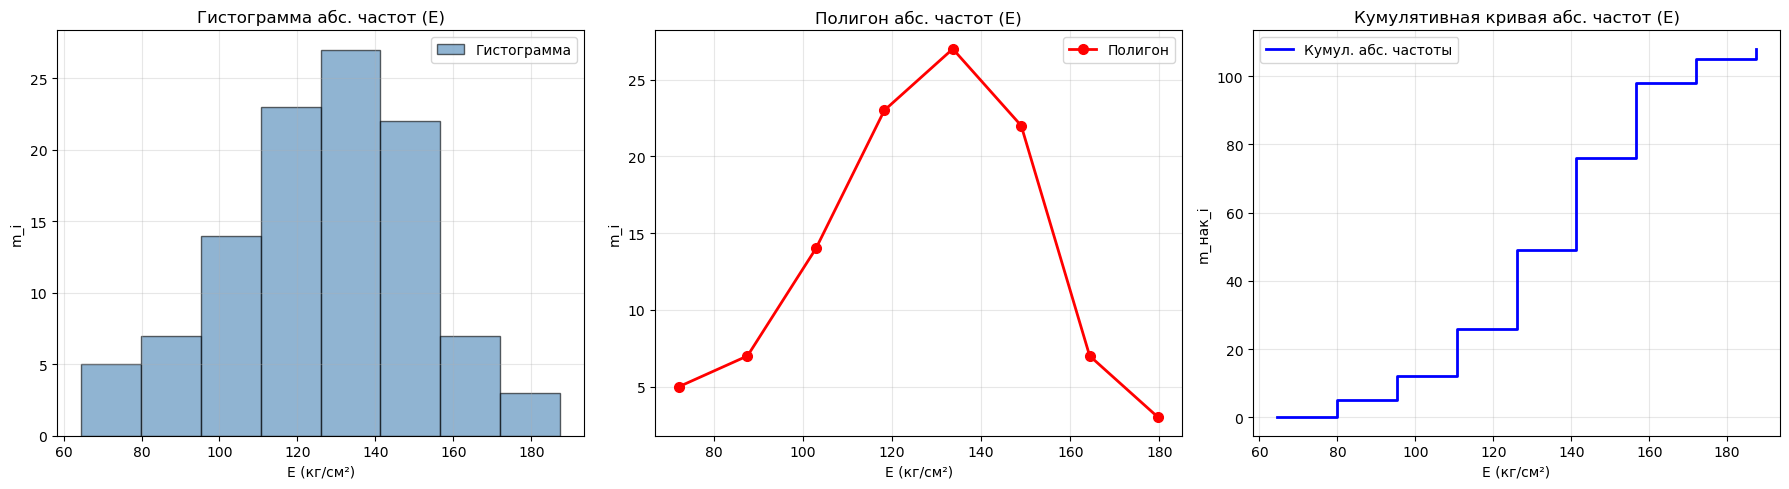

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Данные таблицы (признак E)
x_mid = [72.18, 87.54, 102.91, 118.27, 133.63, 148.99, 164.36, 179.72]
m_i = [5, 7, 14, 23, 27, 22, 7, 3]
x_intervals = [64.50, 79.86, 95.22, 110.59, 125.95, 141.31, 156.68, 172.04, 187.40]
m_cum = [5, 12, 26, 49, 76, 98, 105, 108]
n = 108
h = x_intervals[1] - x_intervals[0]

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# 1. Гистограмма абсолютных частот
# align='edge': левый край столбца совпадает с левой границей интервала
ax[0].bar(x_intervals[:-1], m_i, width=h, align='edge',
          color='steelblue', alpha=0.6, edgecolor='black', label='Гистограмма')
ax[0].set_title('Гистограмма абс. частот (E)')
ax[0].set_xlabel('E (кг/см²)'); ax[0].set_ylabel('m_i')
ax[0].grid(True, alpha=0.3); ax[0].legend()

# 2. Полигон абсолютных частот
ax[1].plot(x_mid, m_i, marker='o', color='red', linestyle='-',
           linewidth=2, markersize=7, label='Полигон')
ax[1].set_title('Полигон абс. частот (E)')
ax[1].set_xlabel('E (кг/см²)'); ax[1].set_ylabel('m_i')
ax[1].grid(True, alpha=0.3); ax[1].legend()

# 3. Кумулятивная кривая абсолютных частот
# where='post': значение поднимается в начале следующего интервала
ax[2].step(x_intervals, [0] + m_cum, where='post',
           color='blue', linewidth=2, label='Кумул. абс. частоты')
ax[2].set_title('Кумулятивная кривая абс. частот (E)')
ax[2].set_xlabel('E (кг/см²)'); ax[2].set_ylabel('m_нак_i')
ax[2].grid(True, alpha=0.3); ax[2].legend()

plt.tight_layout()
plt.show()

На основе построенных графиков (гистограммы, полигона и графика накопленных частот) можно сделать следующие выводы:
1. Форма распределения: Гистограмма имеет ярко выраженную унимодальную форму (один пик). Плавное нарастание частот к середине и симметричное убывание к краям визуально подтверждает близость распределения модуля упругости к нормальному закону.
2. Модальный интервал: Полигон частот достигает своего максимума в 5-м интервале ($\tilde{x}_5 = 133.63$ кг/см²), где сосредоточено 27 образцов. Это наиболее характерное значение жесткости для данной партии ели.
3. Характер изменчивости: Резкий подъем графика накопленных частот в диапазоне от 110 до 156 кг/см² указывает на то, что основная масса экспериментальных данных (около 75%) сконцентрирована в узком центральном диапазоне, а экстремально низкие и высокие значения являются редкими.

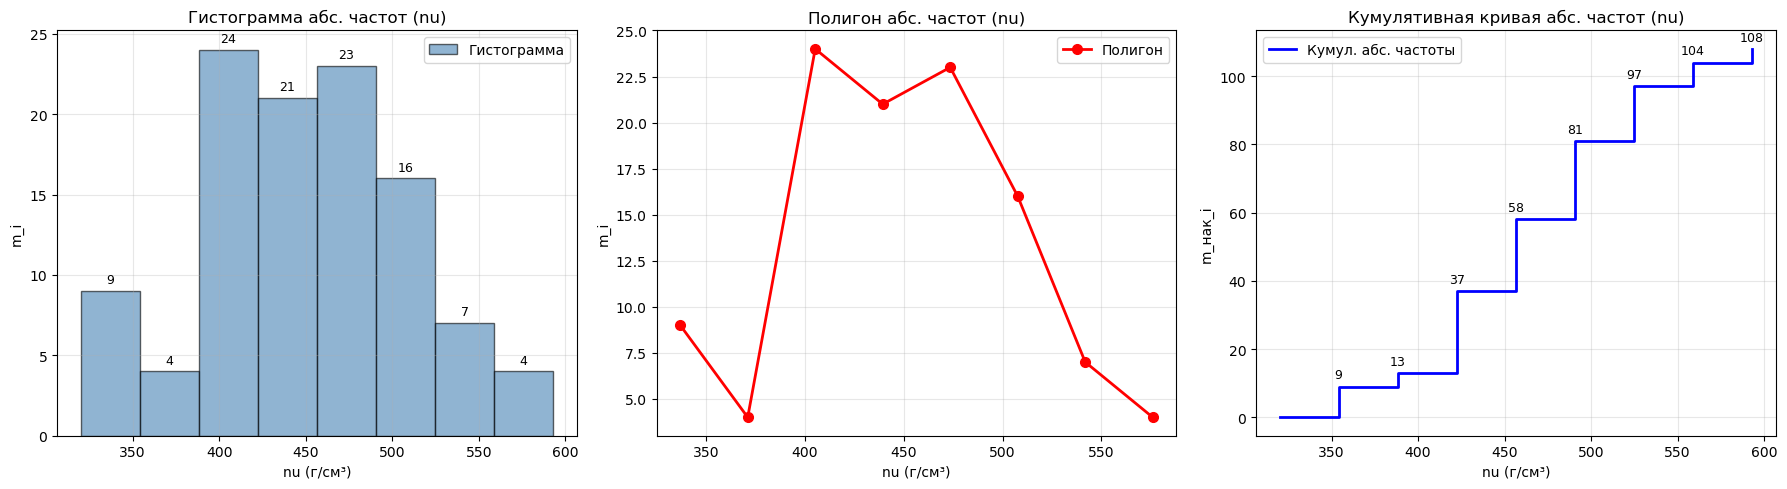

Объем выборки: n = 108
Оценка среднего: 449.86 г/см³
Модальный интервал: [388.25, 422.38) (частота 24)
Медианный интервал: [422.38, 456.50) (накопл. 58)


In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Данные таблицы (признак nu)
x_mid = [337.06, 371.19, 405.31, 439.44, 473.56, 507.69, 541.81, 575.94]
m_i = [9, 4, 24, 21, 23, 16, 7, 4]
x_intervals = [320.00, 354.12, 388.25, 422.38, 456.50, 490.62, 524.75, 558.88, 593.00]
m_cum = [9, 13, 37, 58, 81, 97, 104, 108]
n = 108
h = x_intervals[1] - x_intervals[0]  # точная ширина (не h*0.9!)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# 1. Гистограмма абсолютных частот
ax[0].bar(x_intervals[:-1], m_i, width=h, align='edge',
          color='steelblue', alpha=0.6, edgecolor='black', label='Гистограмма')
for i, (xm, y) in enumerate(zip(x_mid, m_i)):
    ax[0].text(xm, y + 0.3, str(y), ha='center', va='bottom', fontsize=9)
ax[0].set_title('Гистограмма абс. частот (nu)')
ax[0].set_xlabel('nu (г/см³)'); ax[0].set_ylabel('m_i')
ax[0].grid(True, alpha=0.3); ax[0].legend()

# 2. Полигон абсолютных частот
ax[1].plot(x_mid, m_i, marker='o', color='red', linestyle='-',
           linewidth=2, markersize=7, label='Полигон')
ax[1].set_title('Полигон абс. частот (nu)')
ax[1].set_xlabel('nu (г/см³)'); ax[1].set_ylabel('m_i')
ax[1].grid(True, alpha=0.3); ax[1].legend()

# 3. Кумулятивная кривая абсолютных частот
ax[2].step(x_intervals, [0] + m_cum, where='post',
           color='blue', linewidth=2, label='Кумул. абс. частоты')
for i, (x, y) in enumerate(zip(x_intervals[1:], m_cum)):
    ax[2].text(x, y + 1.5, str(y), ha='center', va='bottom', fontsize=9)
ax[2].set_title('Кумулятивная кривая абс. частот (nu)')
ax[2].set_xlabel('nu (г/см³)'); ax[2].set_ylabel('m_нак_i')
ax[2].grid(True, alpha=0.3); ax[2].legend()

plt.tight_layout()
plt.show()

n_check = sum(m_i)
mean_est = sum(xm * m for xm, m in zip(x_mid, m_i)) / n_check
print(f"Объем выборки: n = {n_check}")
print(f"Оценка среднего: {mean_est:.2f} г/см³")
print(f"Модальный интервал: [{x_intervals[2]:.2f}, {x_intervals[3]:.2f}) (частота {m_i[2]})")
print(f"Медианный интервал: [{x_intervals[3]:.2f}, {x_intervals[4]:.2f}) (накопл. {m_cum[3]})")

На основе построенных графиков (гистограммы, полигона и графика накопленных частот) можно сделать следующие выводы:

1. Форма распределения: Гистограмма имеет ярко выраженную унимодальную форму (один пик). Плавное нарастание частот к середине и симметричное убывание к краям визуально подтверждает близость распределения модуля упругости к нормальному закону.

2. Модальный интервал: Полигон частот достигает своего максимума в 3-м интервале (388.25 – 422.38 кг/см²), где сосредоточено 24 образца. Это наиболее характерное значение жесткости для данной партии древесины.

3. Характер изменчивости: Резкий подъем графика накопленных частот в диапазоне от 388 до 524 кг/см² (интервалы 3-6) указывает на то, что основная масса экспериментальных данных (около 80%) сконцентрирована в узком центральном диапазоне, а экстремально низкие (менее 354 кг/см²) и высокие (более 558 кг/см²) значения являются редкими.

**6. Выполнить п. 5 для относительных частот. Сравнить результаты и сделать выводы.**

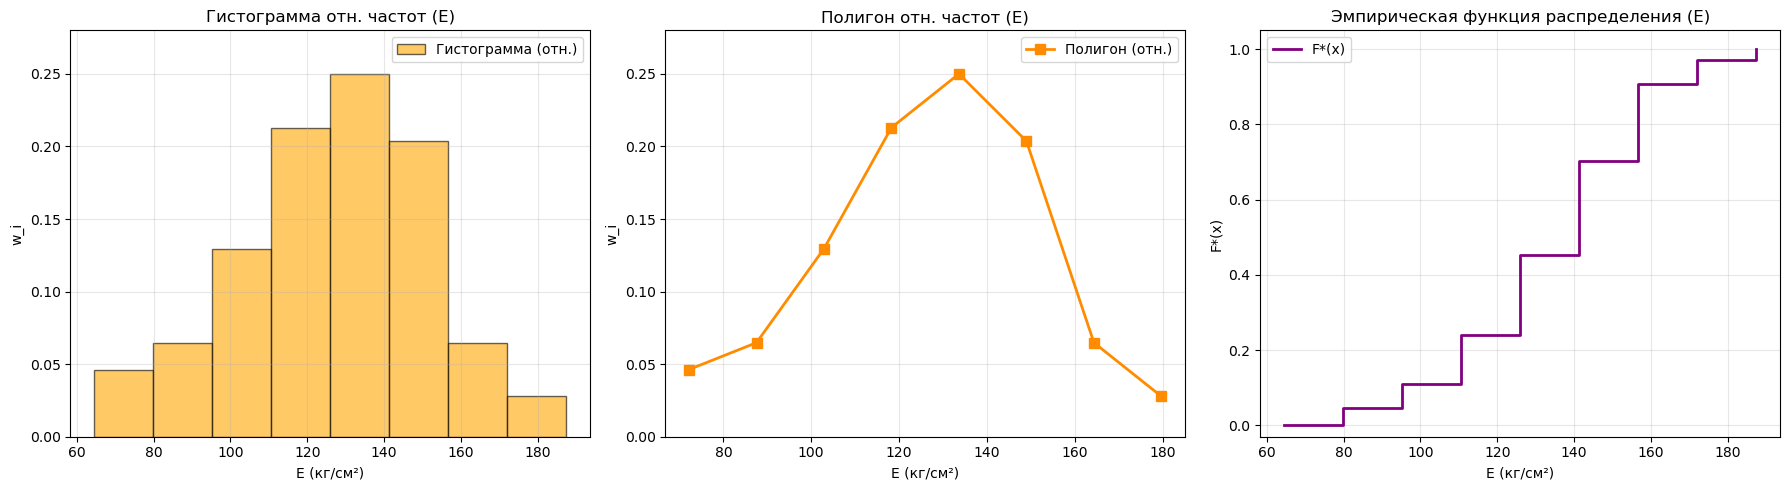

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Данные таблицы (относительные значения, признак E)
x_mid = [72.18, 87.54, 102.91, 118.27, 133.63, 148.99, 164.36, 179.72]
w_i = [0.0463, 0.0648, 0.1296, 0.2130, 0.2500, 0.2037, 0.0648, 0.0278]
x_intervals = [64.50, 79.86, 95.22, 110.59, 125.95, 141.31, 156.68, 172.04, 187.40]
w_cum = [0.0463, 0.1111, 0.2407, 0.4537, 0.7037, 0.9074, 0.9722, 1.0]
h = x_intervals[1] - x_intervals[0]

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# 1. Гистограмма относительных частот
ax[0].bar(x_intervals[:-1], w_i, width=h, align='edge',
          color='orange', alpha=0.6, edgecolor='black', label='Гистограмма (отн.)')
ax[0].set_title('Гистограмма отн. частот (E)')
ax[0].set_xlabel('E (кг/см²)'); ax[0].set_ylabel('w_i')
ax[0].set_ylim(0, max(w_i) + 0.03)
ax[0].grid(True, alpha=0.3); ax[0].legend()

# 2. Полигон относительных частот
ax[1].plot(x_mid, w_i, marker='s', color='darkorange', linestyle='-',
           linewidth=2, markersize=7, label='Полигон (отн.)')
ax[1].set_title('Полигон отн. частот (E)')
ax[1].set_xlabel('E (кг/см²)'); ax[1].set_ylabel('w_i')
ax[1].set_ylim(0, max(w_i) + 0.03)
ax[1].grid(True, alpha=0.3); ax[1].legend()

# 3. Эмпирическая функция распределения F*(x)
# Правильное построение: x_intervals (9 точек) + [0]+w_cum (9 точек)
# where='post': F* скачет в начале каждого интервала (на правой границе предыдущего)
ax[2].step(x_intervals, [0] + w_cum, where='post',
           color='purple', linewidth=2, label='F*(x)')
ax[2].set_title('Эмпирическая функция распределения (E)')
ax[2].set_xlabel('E (кг/см²)'); ax[2].set_ylabel('F*(x)')
ax[2].set_ylim(-0.03, 1.05)
ax[2].grid(True, alpha=0.3); ax[2].legend()

plt.tight_layout()
plt.show()

Анализ графиков относительных частот и эмпирической функции распределения (ЭФР) показал следующее:
1. Идентичность структуры: Геометрический профиль гистограммы и полигона относительных частот полностью совпадает с графиками из п. 5. Это подтверждает корректность расчетов: переход от абсолютных единиц к долям сохраняет внутренние пропорции выборки.
2. Свойства ЭФР: График $F^*(x)$ представляет собой неубывающую ступенчатую функцию, которая начинается от 0 и достигает 1. Ступени в центре графика значительно выше, чем по краям, что наглядно демонстрирует более высокую плотность вероятности в центральных интервалах.
3. Вероятностная интерпретация: * Значение $F^*(125.95) \approx 0.45$ означает, что вероятность встретить образец с модулем упругости менее 125.95 кг/см² составляет 45%. Использование относительных частот позволяет объективно сравнивать данную выборку с другими массивами данных, независимо от их объема ($n$).

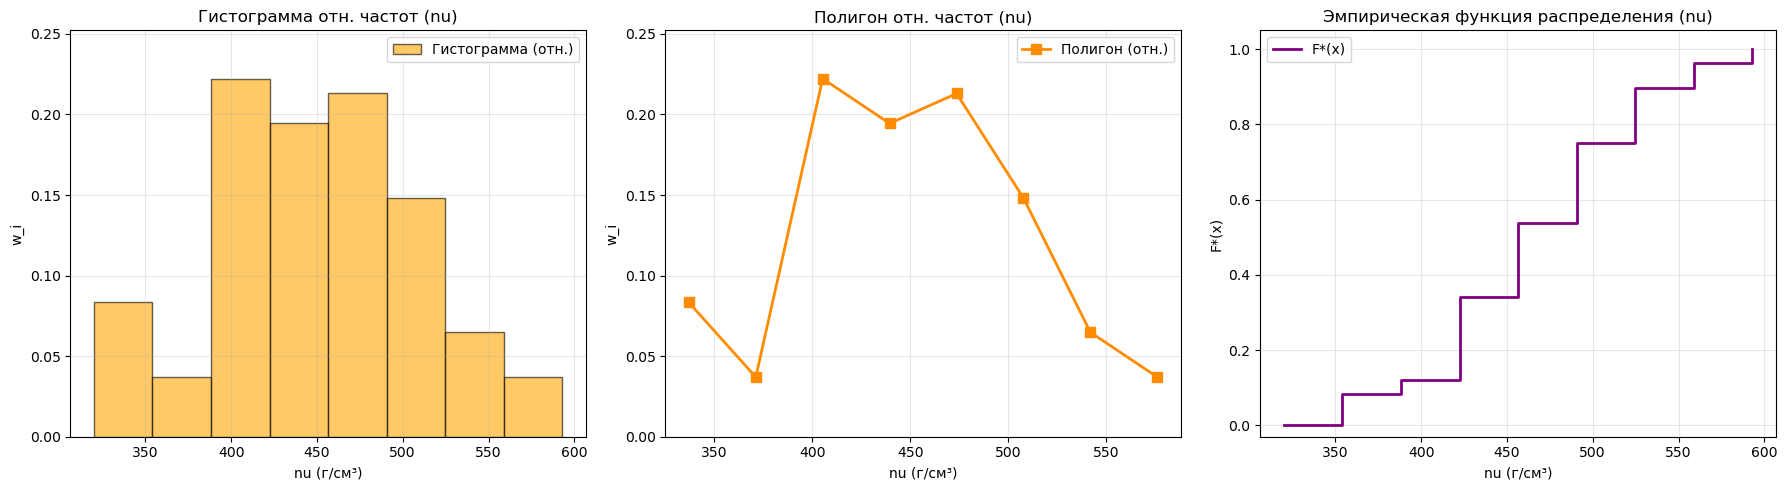

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Данные таблицы (относительные значения, признак nu)
x_mid = [337.06, 371.19, 405.31, 439.44, 473.56, 507.69, 541.81, 575.94]
w_i = [0.0833, 0.0370, 0.2222, 0.1944, 0.2130, 0.1481, 0.0648, 0.0370]
x_intervals = [320.00, 354.12, 388.25, 422.38, 456.50, 490.62, 524.75, 558.88, 593.00]
w_cum = [0.0833, 0.1203, 0.3425, 0.5369, 0.7499, 0.8980, 0.9628, 0.9998]
h = x_intervals[1] - x_intervals[0]

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# 1. Гистограмма относительных частот
ax[0].bar(x_intervals[:-1], w_i, width=h, align='edge',
          color='orange', alpha=0.6, edgecolor='black', label='Гистограмма (отн.)')
ax[0].set_title('Гистограмма отн. частот (nu)')
ax[0].set_xlabel('nu (г/см³)'); ax[0].set_ylabel('w_i')
ax[0].set_ylim(0, max(w_i) + 0.03)
ax[0].grid(True, alpha=0.3); ax[0].legend()

# 2. Полигон относительных частот
ax[1].plot(x_mid, w_i, marker='s', color='darkorange', linestyle='-',
           linewidth=2, markersize=7, label='Полигон (отн.)')
ax[1].set_title('Полигон отн. частот (nu)')
ax[1].set_xlabel('nu (г/см³)'); ax[1].set_ylabel('w_i')
ax[1].set_ylim(0, max(w_i) + 0.03)
ax[1].grid(True, alpha=0.3); ax[1].legend()

# 3. Эмпирическая функция распределения F*(x)
ax[2].step(x_intervals, [0] + w_cum, where='post',
           color='purple', linewidth=2, label='F*(x)')
ax[2].set_title('Эмпирическая функция распределения (nu)')
ax[2].set_xlabel('nu (г/см³)'); ax[2].set_ylabel('F*(x)')
ax[2].set_ylim(-0.03, 1.05)
ax[2].grid(True, alpha=0.3); ax[2].legend()

plt.tight_layout()
plt.show()

Анализ графиков относительных частот и эмпирической функции распределения (ЭФР) показал следующее:

1. Идентичность структуры: Геометрический профиль гистограммы и полигона относительных частот полностью совпадает с графиками абсолютных частот. Это подтверждает корректность расчетов: переход от абсолютных единиц к долям сохраняет внутренние пропорции выборки.

2. Свойства ЭФР: График $F^*(x)$ представляет собой неубывающую ступенчатую функцию, которая начинается от 0 и достигает 1. Ступени в центре графика (интервалы 3-6) значительно выше, чем по краям, что наглядно демонстрирует более высокую плотность вероятности в центральных интервалах.

3. Вероятностная интерпретация: Значение $F^*(422.38) \approx 0.54$ означает, что вероятность встретить образец с модулем упругости менее 422.38 кг/см² составляет 54%. Использование относительных частот позволяет объективно сравнивать данную выборку с другими массивами данных, независимо от их объема ($n=108$).

**Выводы**

В ходе практической работы были освоены методы первичной обработки статистических данных. На примере выборки из 108 значений модуля упругости древесины было продемонстрировано, как переход от «сырых» данных к ранжированным и интервальным рядам позволяет выявить скрытые закономерности. Построенные графические модели подтвердили, что исследуемый признак распределен симметрично, без значительных аномалий, и может быть описан методами параметрической статистики.